In [ ]:
!pip install dask[distributed] xmltodict pyarrow  # Dask complete + XML parser


In [ ]:
!pip uninstall -y numpy scikit-learn
!pip install numpy==1.26.4 scikit-learn==1.4.2


In [ ]:
pip install ultralytics

In [ ]:
# Install if needed (Kaggle has it, but confirm)
!pip install --upgrade plotly


In [ ]:
!pip install --upgrade plotly kaleido

In [1]:
import kagglehub
import os
import random
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image
import dask
import dask.bag as db
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import pandas as pd
import warnings
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [2]:

# Suppress OpenCV warnings
warnings.filterwarnings('ignore')



In [3]:
# Download latest version
path = kagglehub.dataset_download("a2015003713/militaryaircraftdetectiondataset")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/militaryaircraftdetectiondataset


In [4]:

# Define class names
class_names = ['A-10', 'A-400M', 'AG-600',
               'AH-64', 'AV-8B', 'An-124',
               'An-22', 'An-225', 'An-72',
               'B-1', 'B-2', 'B-21', 'B-52',
               'Be-200', 'C-1', 'C-130', 'C-17',
               'C-2', 'C-390', 'C-5', 'CH-47', 'CH-53',
               'CL-415', 'E-2', 'E-7', 'EF-2000', 'EMB-314',
               'F-117', 'F-14', 'F-15', 'F-16', 'F-22', 'F-35',
               'F-4', 'F/A-18', 'H-6', 'Il-76', 'J-10', 'J-20', 'J-35',
               'J-36', 'J-50', 'JAS-39', 'JF-17', 'JH-7', 'KAAN', 'KC-135',
               'KF-21', 'KJ-600', 'Ka-27', 'Ka-52', 'MQ-9', 'Mi-24', 'Mi-26',
               'Mi-28', 'Mi-8', 'Mig-29', 'Mig-31', 'Mirage2000', 'P-3', 'RQ-4',
               'Rafale', 'SR-71', 'Su-24', 'Su-25', 'Su-34', 'Su-57', 'TB-001', 'TB-2',
               'Tejas', 'Tornado', 'Tu-160', 'Tu-22M', 'Tu-95', 'U-2', 'UH-60', 'US-2',
               'V-22', 'V-280', 'Vulcan', 'WZ-10', 'WZ-7', 'WZ-9', 'XB-70', 'Y-20', 'YF-23', 'Z-10', 'Z-19']


In [5]:

dataset_path = os.path.join(path, 'dataset')

print("="*60)
print("🔍 DIAGNOSTIC CHECK")
print("="*60)

# Get a sample image and its CSV
image_extensions = ('.jpg', '.jpeg', '.png')
image_files = [f for f in os.listdir(dataset_path) if f.endswith(image_extensions)]

print(f"\n1️⃣ Total image files found: {len(image_files)}")
print(f"   Sample images: {image_files[:3]}")

# Check first CSV
if len(image_files) > 0:
    sample_img = image_files[0]
    csv_file = sample_img.rsplit('.', 1)[0] + '.csv'
    csv_path = os.path.join(dataset_path, csv_file)
    img_path = os.path.join(dataset_path, sample_img)
    
    print(f"\n2️⃣ Sample files:")
    print(f"   Image: {sample_img}")
    print(f"   CSV: {csv_file}")
    print(f"   CSV exists: {os.path.exists(csv_path)}")
    print(f"   Image exists: {os.path.exists(img_path)}")
    
    if os.path.exists(csv_path):
        print(f"\n3️⃣ CSV Contents:")
        # Read raw CSV
        with open(csv_path, 'r') as f:
            lines = f.readlines()
        print(f"   Total lines: {len(lines)}")
        print(f"   First 5 lines (raw):")
        for i, line in enumerate(lines[:5]):
            print(f"      Line {i}: {repr(line)}")
        
        print(f"\n4️⃣ Pandas DataFrame:")
        try:
            df = pd.read_csv(csv_path)
            print(f"   Shape: {df.shape}")
            print(f"   Columns: {list(df.columns)}")
            print(f"\n   DataFrame head:")
            print(df.head())
            print(f"\n   Column types:")
            print(df.dtypes)
        except Exception as e:
            print(f"   ❌ Error reading CSV: {e}")
    
    if os.path.exists(img_path):
        print(f"\n5️⃣ Image Info:")
        image = cv2.imread(img_path)
        if image is not None:
            h, w, c = image.shape
            print(f"   Dimensions: {w}x{h}, Channels: {c}")
        else:
            print(f"   ❌ Could not read image")

print("\n" + "="*60)

🔍 DIAGNOSTIC CHECK

1️⃣ Total image files found: 22177
   Sample images: ['56cb6f7c292bdcc412c491f88954f19c.jpg', '77e7a26de432de05fbe0d2a28dc38498.jpg', 'e533357337720e34c6d71d1d74e390f1.jpg']

2️⃣ Sample files:
   Image: 56cb6f7c292bdcc412c491f88954f19c.jpg
   CSV: 56cb6f7c292bdcc412c491f88954f19c.csv
   CSV exists: True
   Image exists: True

3️⃣ CSV Contents:
   Total lines: 2
   First 5 lines (raw):
      Line 0: 'filename,width,height,class,xmin,ymin,xmax,ymax\n'
      Line 1: '56cb6f7c292bdcc412c491f88954f19c,1197,899,C130,99,283,1033,649\n'

4️⃣ Pandas DataFrame:
   Shape: (1, 8)
   Columns: ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

   DataFrame head:
                           filename  width  height class  xmin  ymin  xmax  \
0  56cb6f7c292bdcc412c491f88954f19c   1197     899  C130    99   283  1033   

   ymax  
0   649  

   Column types:
filename    object
width        int64
height       int64
class       object
xmin         int64
ymin      

In [6]:

# Create a mapping from class name to index
def normalize_name(name):
    """Normalize class names by removing special characters"""
    return name.replace('-', '').replace('/', '').upper()

class_name_to_idx = {normalize_name(name): name for name in class_names}



In [7]:

# ==================== VISUALIZATION WITH DASK DATA ====================

def plot_random_annotated_images_dask(folder_path, df_stats=None, grid_size=(5, 5), image_size=(200, 200)):
    """
    Plot random annotated images, optionally using pre-computed Dask statistics
    """
    print(f"🎨 Plotting random annotated images...")
    
    image_extensions = ('.jpg', '.jpeg', '.png')
    image_files = [f for f in os.listdir(folder_path) if f.endswith(image_extensions)]
    
    # Find valid pairs
    valid_pairs = []
    for img_file in image_files:
        ann_file = img_file.rsplit('.', 1)[0] + '.csv'
        if os.path.exists(os.path.join(folder_path, ann_file)):
            valid_pairs.append((img_file, ann_file))
    
    if len(valid_pairs) == 0:
        print("❌ No valid image-annotation pairs found!")
        return
    
    selected_files = random.sample(valid_pairs, min(25, len(valid_pairs)))
    
    fig, axes = plt.subplots(*grid_size, figsize=(15, 15))
    axes = axes.ravel()
    
    for idx, (img_file, ann_file) in enumerate(selected_files):
        img_path = os.path.join(folder_path, img_file)
        image = cv2.imread(img_path)
        if image is None:
            continue
        
        h, w, _ = image.shape
        ann_path = os.path.join(folder_path, ann_file)
        
        with open(ann_path, 'r') as f:
            annotations = f.readlines()
        
        for i, ann in enumerate(annotations):
            if i == 0:  # Skip header
                continue
            
            ann = ann.strip()
            if not ann:
                continue
            
            try:
                parts = ann.split(',')
                class_name_raw = parts[1].strip()
                class_name_normalized = normalize_name(class_name_raw)
                
                if class_name_normalized in class_name_to_idx:
                    display_name = class_name_to_idx[class_name_normalized]
                else:
                    display_name = class_name_raw
                
                x_center = float(parts[2].strip())
                y_center = float(parts[3].strip())
                width = float(parts[4].strip())
                height = float(parts[5].strip())
                
                x_center_px = x_center * w
                y_center_px = y_center * h
                width_px = width * w
                height_px = height * h
                
                top_left = (int(x_center_px - width_px / 2), int(y_center_px - height_px / 2))
                bottom_right = (int(x_center_px + width_px / 2), int(y_center_px + height_px / 2))
                
                cv2.rectangle(image, top_left, bottom_right, (0, 0, 255), 2)
                cv2.putText(image, display_name, (top_left[0], top_left[1] - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (144, 238, 144), 2)
            except (ValueError, IndexError):
                pass
        
        small_image = cv2.resize(image, image_size)
        axes[idx].imshow(cv2.cvtColor(small_image, cv2.COLOR_BGR2RGB))
        axes[idx].axis('off')
    
    for j in range(len(selected_files), grid_size[0] * grid_size[1]):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    print("✅ Plot ready!\n")
    plt.show()

In [8]:

def process_single_annotation(csv_path, folder_path):
    try:
        df = pd.read_csv(csv_path)
        image_name = df.iloc[0]['filename']
        img_path = os.path.join(folder_path, image_name + '.jpg')
        
        if not os.path.exists(img_path):
            img_path = os.path.join(folder_path, image_name + '.png')
        if not os.path.exists(img_path):
            return None  # skip if image missing
        
        image = cv2.imread(img_path)
        if image is None:
            return None
        
        img_h, img_w, _ = image.shape
        
        results = []
        for _, row in df.iterrows():
            bbox_width_px = row['xmax'] - row['xmin']
            bbox_height_px = row['ymax'] - row['ymin']
            results.append({
                'filename': row['filename'],
                'class_name': row['class'],
                'img_width': img_w,
                'img_height': img_h,
                'bbox_width_px': bbox_width_px,
                'bbox_height_px': bbox_height_px
            })
        return results
    except Exception as e:
        print(f"⚠️ Error processing {csv_path}: {e}")
        return None


In [9]:
def compute_dataset_statistics_dask(folder_path, sample_size=None):
    """
    Compute dataset statistics using Dask for parallel processing
    """
    print("🚀 Computing dataset statistics with Dask...\n")
    
    image_extensions = ('.jpg', '.jpeg', '.png')
    image_files = [f for f in os.listdir(folder_path) if f.endswith(image_extensions)]
    
    # Get all annotation file paths
    ann_files = [os.path.join(folder_path, f.rsplit('.', 1)[0] + '.csv') 
                 for f in image_files 
                 if os.path.exists(os.path.join(folder_path, f.rsplit('.', 1)[0] + '.csv'))]
    
    # Optional: sample for faster processing
    if sample_size and sample_size < len(ann_files):
        ann_files = random.sample(ann_files, sample_size)
        print(f"📊 Using sample of {sample_size} files for faster processing")
    
    print(f"📁 Processing {len(ann_files)} annotation files...")
    
    # Create Dask Bag for parallel processing
    bag = db.from_sequence(ann_files, npartitions=min(os.cpu_count() * 4, len(ann_files)))
    
    # Process all annotations in parallel
    print("⏳ Processing in parallel (this may take a moment)...\n")
    with ProgressBar():
        results = bag.map(lambda x: process_single_annotation(x, folder_path)).compute()
    
    # Flatten results and convert to DataFrame
    all_data = []
    skipped = 0
    for result in results:
        if result:
            all_data.extend(result)
        else:
            skipped += 1
    
    print(f"\n✅ Processed: {len(results) - skipped}/{len(results)} files")
    print(f"⚠️  Skipped: {skipped} files")
    
    if not all_data:
        print("❌ No valid data found!")
        print("\n💡 Tip: Check CSV structure - run the inspection cell above")
        return None
    
    df = pd.DataFrame(all_data)
    
    # Compute statistics
    print("\n" + "="*60)
    print("📊 DATASET STATISTICS")
    print("="*60)
    print(f"📸 Total images: {df['filename'].nunique()}")
    print(f"📦 Total bounding boxes: {len(df)}")
    print(f"🏷️  Unique classes: {df['class_name'].nunique()}")
    
    print("\n" + "-"*60)
    print("📊 CLASS DISTRIBUTION (Top 15)")
    print("-"*60)
    class_counts = df['class_name'].value_counts().head(15)
    for i, (class_name, count) in enumerate(class_counts.items(), 1):
        print(f"{i:2d}. {class_name:15s}: {count:5d} ({count/len(df)*100:.1f}%)")
    
    print("\n" + "-"*60)
    print("📦 BOUNDING BOX STATISTICS (pixels)")
    print("-"*60)
    print(f"Width  → Mean: {df['bbox_width_px'].mean():7.2f}  Std: {df['bbox_width_px'].std():7.2f}")
    print(f"         Min:  {df['bbox_width_px'].min():7.2f}  Max: {df['bbox_width_px'].max():7.2f}")
    print(f"Height → Mean: {df['bbox_height_px'].mean():7.2f}  Std: {df['bbox_height_px'].std():7.2f}")
    print(f"         Min:  {df['bbox_height_px'].min():7.2f}  Max: {df['bbox_height_px'].max():7.2f}")
    
    print("\n" + "-"*60)
    print("🖼️  IMAGE RESOLUTION STATISTICS")
    print("-"*60)
    print(f"Width  → Mean: {df['img_width'].mean():7.0f}  Min: {df['img_width'].min():5.0f}  Max: {df['img_width'].max():5.0f}")
    print(f"Height → Mean: {df['img_height'].mean():7.0f}  Min: {df['img_height'].min():5.0f}  Max: {df['img_height'].max():5.0f}")
    print("="*60 + "\n")
    
    return df


🚀 Computing dataset statistics with Dask...

📁 Processing 22177 annotation files...
⏳ Processing in parallel (this may take a moment)...

[########################################] | 100% Completed | 266.66 s

✅ Processed: 22177/22177 files
⚠️  Skipped: 0 files

📊 DATASET STATISTICS
📸 Total images: 22177
📦 Total bounding boxes: 39482
🏷️  Unique classes: 96

------------------------------------------------------------
📊 CLASS DISTRIBUTION (Top 15)
------------------------------------------------------------
 1. F16            :  1941 (4.9%)
 2. F18            :  1750 (4.4%)
 3. C130           :  1581 (4.0%)
 4. F15            :  1541 (3.9%)
 5. F35            :  1534 (3.9%)
 6. V22            :   909 (2.3%)
 7. J20            :   860 (2.2%)
 8. EF2000         :   834 (2.1%)
 9. C2             :   830 (2.1%)
10. Rafale         :   800 (2.0%)
11. A10            :   773 (2.0%)
12. J10            :   761 (1.9%)
13. C17            :   741 (1.9%)
14. F4             :   724 (1.8%)
15. F22     

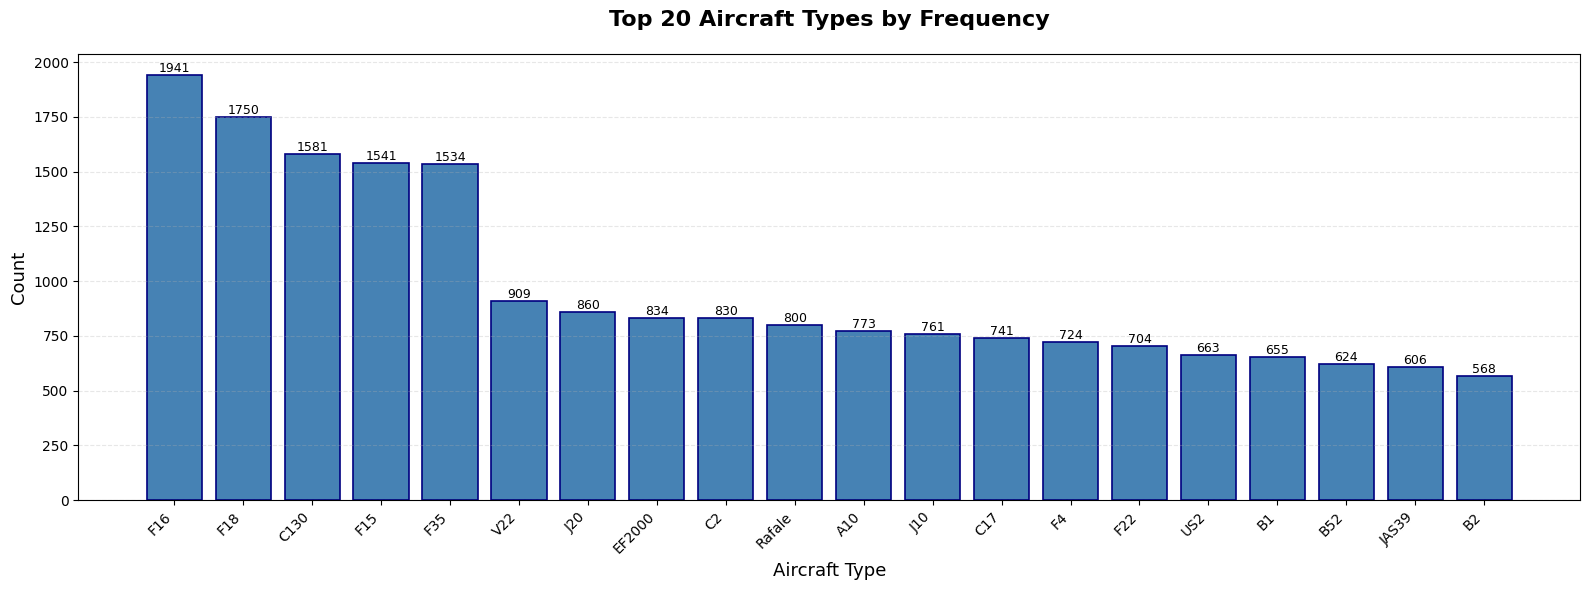

📊 Generating bounding box distribution charts...


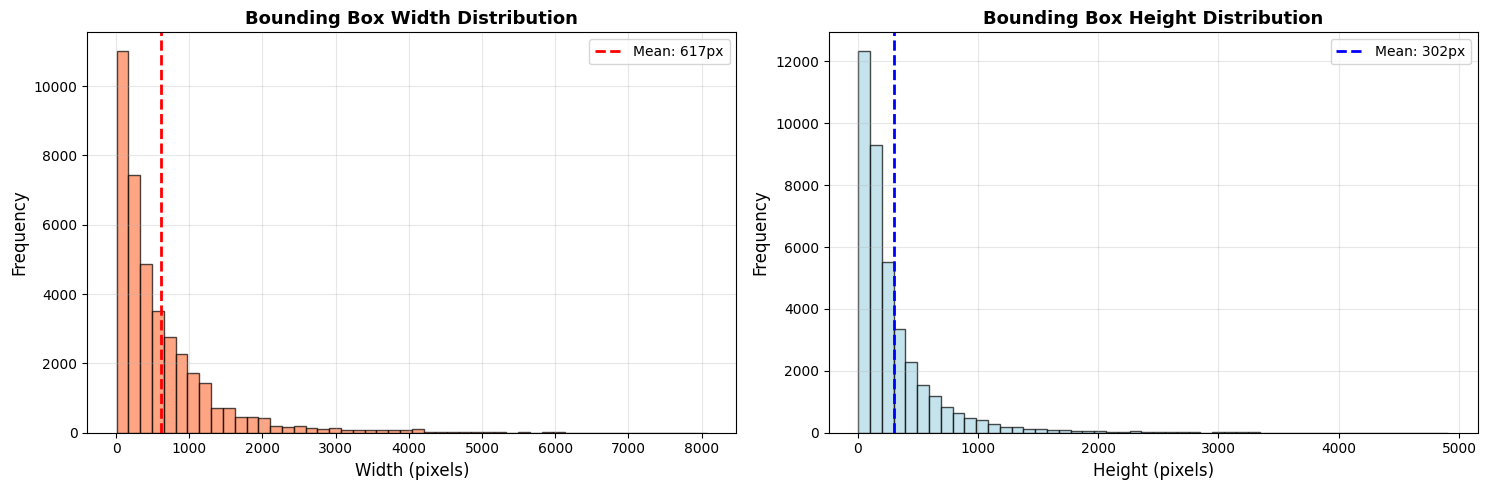

In [10]:

# Compute statistics using Dask
df_stats = compute_dataset_statistics_dask(dataset_path)

# Plot visualizations
if df_stats is not None:
    # Class distribution chart
    print("📊 Generating class distribution chart...")
    plt.figure(figsize=(16, 6))
    class_counts = df_stats['class_name'].value_counts().head(20)
    bars = plt.bar(range(len(class_counts)), class_counts.values, color='steelblue', edgecolor='navy', linewidth=1.2)
    plt.xticks(range(len(class_counts)), class_counts.index, rotation=45, ha='right')
    plt.title("Top 20 Aircraft Types by Frequency", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Aircraft Type", fontsize=13)
    plt.ylabel("Count", fontsize=13)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Bbox size distribution
    print("📊 Generating bounding box distribution charts...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.hist(df_stats['bbox_width_px'], bins=50, color='coral', alpha=0.7, edgecolor='black')
    ax1.axvline(df_stats['bbox_width_px'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_stats["bbox_width_px"].mean():.0f}px')
    ax1.set_xlabel('Width (pixels)', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Bounding Box Width Distribution', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2.hist(df_stats['bbox_height_px'], bins=50, color='lightblue', alpha=0.7, edgecolor='black')
    ax2.axvline(df_stats['bbox_height_px'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {df_stats["bbox_height_px"].mean():.0f}px')
    ax2.set_xlabel('Height (pixels)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Bounding Box Height Distribution', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


🎨 Plotting random annotated images...
✅ Plot ready!



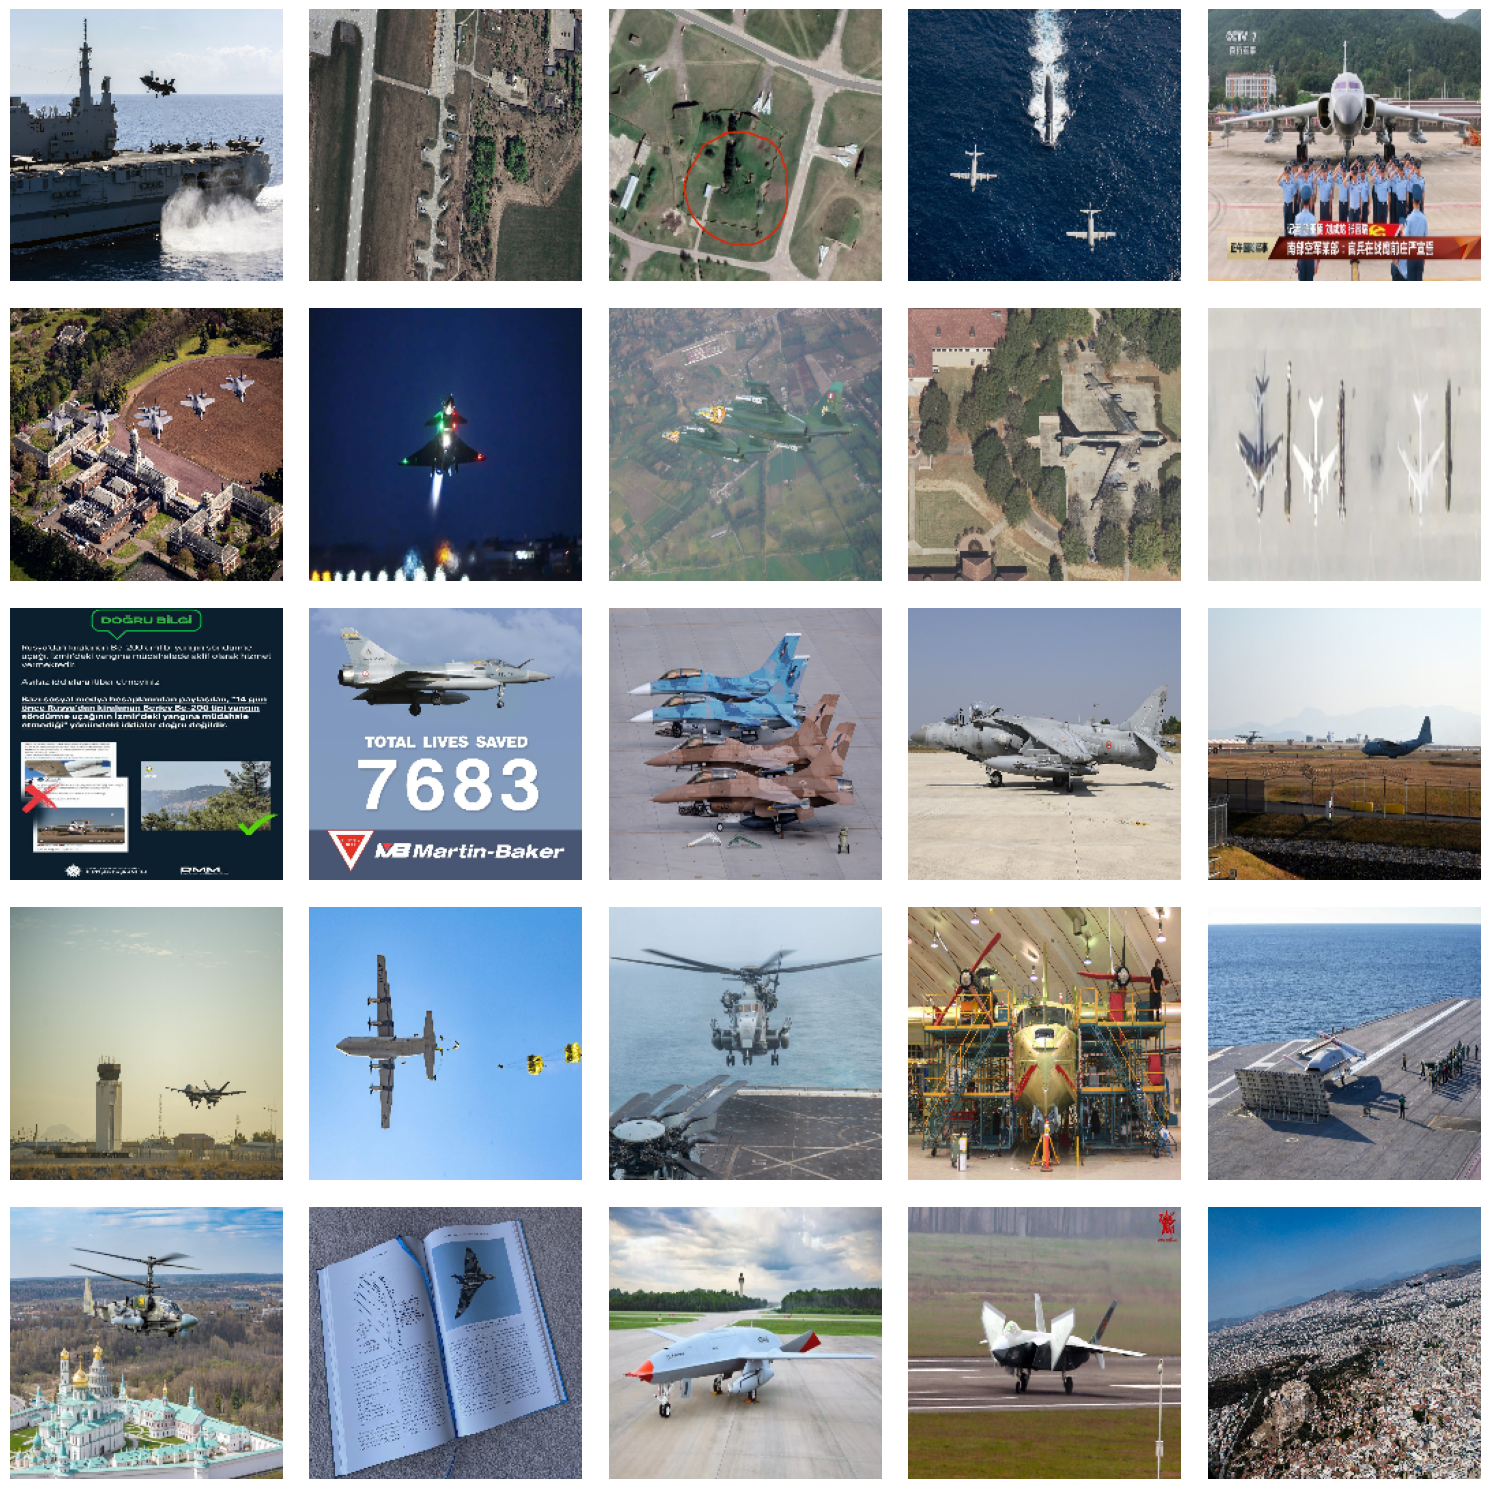

✨ All done!


In [11]:

# Plot sample images
plot_random_annotated_images_dask(dataset_path, df_stats)

print("✨ All done!")

In [12]:
# 1. Missing Values & Outliers Cleaning (Week 1: Data Quality)
print("\n📊 Missing Values Check")
print(df_stats.isnull().sum())  # Expect 0; if any, drop: df_stats = df_stats.dropna()
 
# Outliers: Remove extreme bboxes (e.g., >3 SD from mean)
mean_w, std_w = df_stats['bbox_width_px'].mean(), df_stats['bbox_width_px'].std()
mean_h, std_h = df_stats['bbox_height_px'].mean(), df_stats['bbox_height_px'].std()
df_clean = df_stats[(df_stats['bbox_width_px'].between(mean_w - 3*std_w, mean_w + 3*std_w)) &
                    (df_stats['bbox_height_px'].between(mean_h - 3*std_h, mean_h + 3*std_h))]
print(f"Removed {len(df_stats) - len(df_clean)} outliers (~{((len(df_stats) - len(df_clean))/len(df_stats)*100):.1f}%)")
 

df_clean.to_parquet('clean_meta.parquet', engine='pyarrow')



📊 Missing Values Check
filename          0
class_name        0
img_width         0
img_height        0
bbox_width_px     0
bbox_height_px    0
dtype: int64
Removed 1329 outliers (~3.4%)


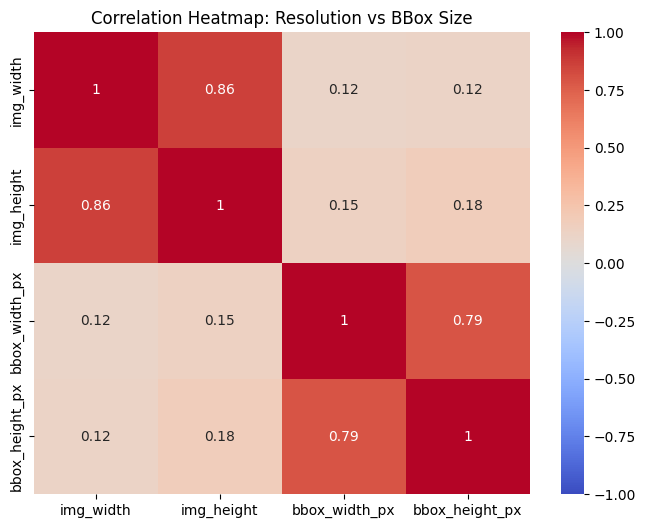

In [13]:

corr = df_clean[['img_width', 'img_height', 'bbox_width_px', 'bbox_height_px']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Resolution vs BBox Size')
plt.savefig('corr_heatmap.png')
plt.show()
# Insight: High correlation between img_width and bbox_width_px? Suggests larger images have larger aircraft.
 

In [14]:

# 3. Dimensionality Reduction (Week 7: PCA)

features = df_clean[['img_width', 'img_height', 'bbox_width_px', 'bbox_height_px']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
pca = PCA(n_components=2)
pca_fit = pca.fit_transform(features_scaled)
print(f"Explained Variance: {pca.explained_variance_ratio_} (Total: {sum(pca.explained_variance_ratio_):.2f})")
 
 

Explained Variance: [0.52694106 0.38615685] (Total: 0.91)


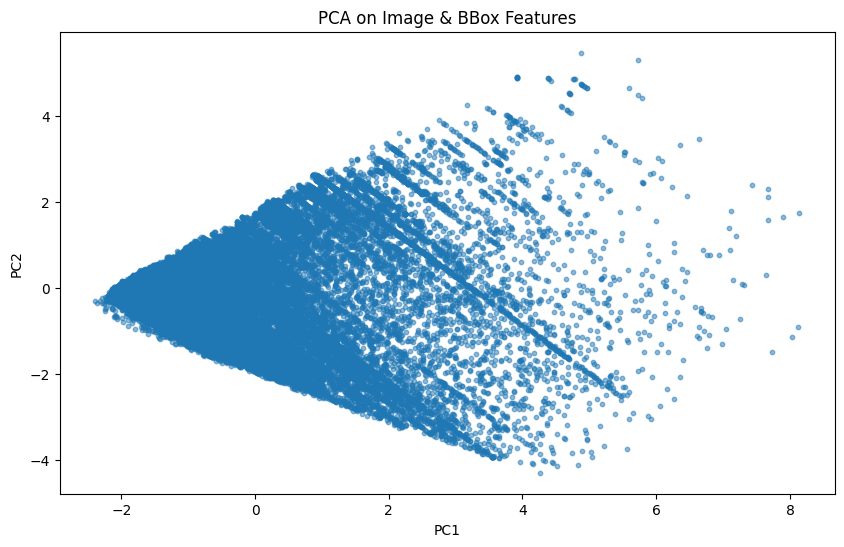

In [15]:

# Plot PCA
plt.figure(figsize=(10, 6))
plt.scatter(pca_fit[:,0], pca_fit[:,1], alpha=0.5, s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA on Image & BBox Features')
plt.savefig('pca_scatter.png')
plt.show()
# Insight: PC1 likely captures size variation; use for clustering classes.

In [16]:
import kaleido
kaleido.get_chrome_sync()

PosixPath('/usr/local/lib/python3.11/dist-packages/choreographer/cli/browser_exe/chrome-linux64/chrome')

In [17]:

# Data check
print(f"df_clean rows: {len(df_clean)}")  # Confirm >0

if len(df_clean) > 0:
    fig = px.histogram(df_clean, x='bbox_width_px', nbins=50, 
                       title='Interactive BBox Width Distribution', marginal='box')
    fig.add_vline(x=df_clean['bbox_width_px'].mean(), line_dash='dash', line_color='red')
    fig.add_vline(x=df_clean['bbox_width_px'].std(), line_dash='dot', line_color='green')
    # Display interactive (error-free)
    fig.show(renderer='iframe')  # Reliable for Kaggle
    
    # Export (now error-free with kaleido)
    fig.write_html('bbox_width_hist.html')  # For iframe embed in Medium
    fig.write_image('bbox_width_hist.png')  # Static PNG for blog upload
else:
    print("No data—check cleaning (e.g., adjust outlier threshold to 4*std if too aggressive)")

df_clean rows: 38153


In [18]:
class_counts = df_clean['class_name'].value_counts()
top15 = class_counts.head(15)
print(top15)
print(f"\nTop 15 classes represent {top15.sum():,} boxes → {top15.sum()/len(df_clean):.1%} of total")

class_name
F16       1857
F18       1690
C130      1527
F35       1484
F15       1482
V22        873
J20        854
EF2000     812
C2         785
Rafale     779
J10        747
A10        744
F4         701
C17        694
F22        677
Name: count, dtype: int64

Top 15 classes represent 15,706 boxes → 41.2% of total


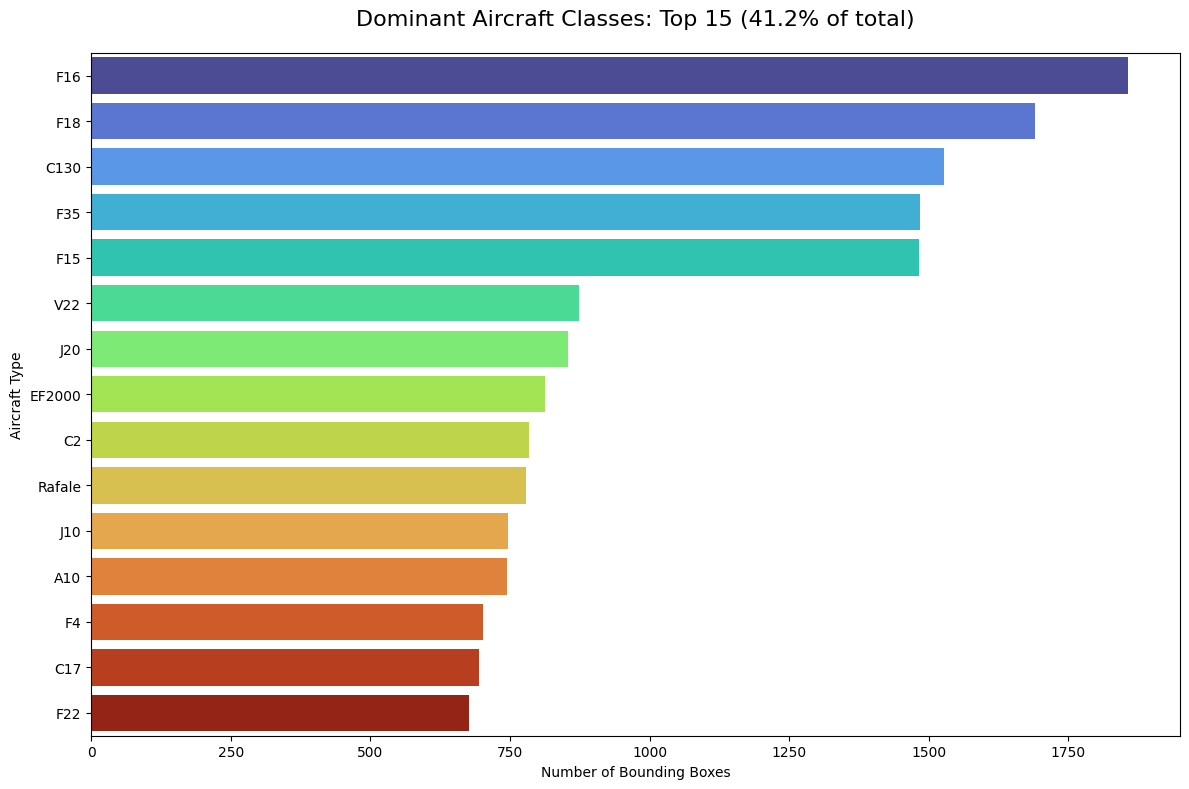

In [19]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top15.values, y=top15.index, palette='turbo')
plt.title('Dominant Aircraft Classes: Top 15 (41.2% of total)', fontsize=16, pad=20)
plt.xlabel('Number of Bounding Boxes')
plt.ylabel('Aircraft Type')
plt.tight_layout()
plt.show()

In [20]:
fig = px.histogram(df_clean, x='bbox_width_px', nbins=60, marginal='box',
                   title='Bounding-Box Width Distribution (Skewed Reality)')
fig.add_vline(x=df_clean['bbox_width_px'].mean(), line_dash="dash", line_color="red")
fig.add_vline(x=df_clean['bbox_width_px'].std(), line_dash="dot", line_color="red")
fig.show(renderer="iframe")

CAUSAL INFERENCE: Bounding Box Size → Detection Difficulty

✅ Loaded 38,153 records with 96 aircraft classes

----------------------------------------------------------------------
STEP 1: Define Causal Variables
----------------------------------------------------------------------
✓ Treatment Variable: Large BBox (0=Small, 1=Large)
  - Small BBoxes: 19,077 (50.0%)
  - Large BBoxes: 19,076 (50.0%)

✓ Outcome Variable: Rare Class (0=Common, 1=Rare)
  - Common Classes: 19,248 (50.4%)
  - Rare Classes: 18,905 (49.6%)

✓ Confounders:
  - Image Area (resolution)
  - BBox Aspect Ratio
  - Image Width & Height

----------------------------------------------------------------------
STEP 2: Naive Association (Before Causal Adjustment)
----------------------------------------------------------------------
📊 Rare Class Rate by BBox Size:
   Small BBoxes → 45.8% are rare classes
   Large BBoxes → 53.3% are rare classes
   Naive Difference: 7.59 percentage points

⚠️  CONFOUNDING DETECTED: Large b

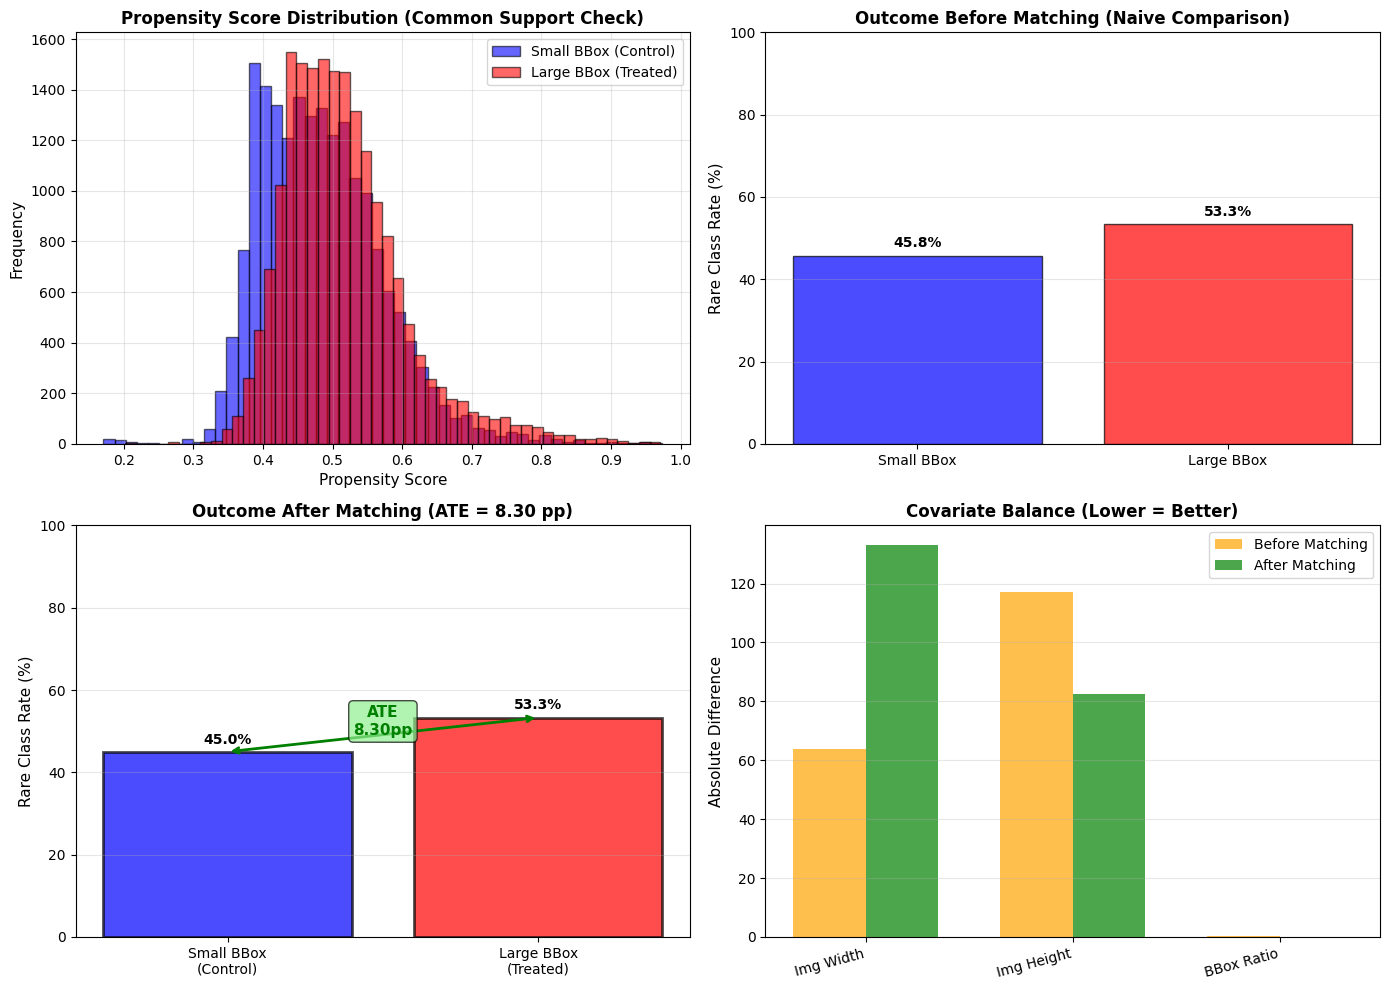


📊 Generating Causal DAG (Directed Acyclic Graph)...
✓ Saved: causal_dag.png


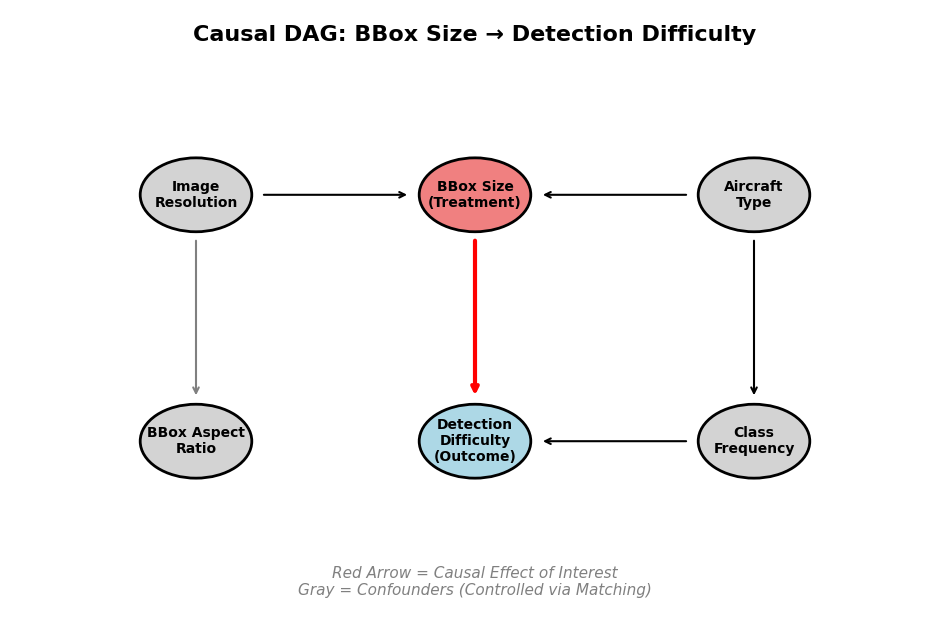


----------------------------------------------------------------------
STEP 6: Sensitivity Analysis
----------------------------------------------------------------------
 Caliper  Matched Pairs  ATE (pp)
    0.05          16169  8.380234
    0.10          16981  8.297509
    0.15          17828  8.413731
    0.20          18377  8.456222

✅ Sensitivity analysis shows ATE is robust across different matching criteria

🎯 CAUSAL INFERENCE SUMMARY
Research Question: Does BBox size causally affect detection difficulty?

Method: Propensity Score Matching
Matched Pairs: 16,981

CAUSAL EFFECT (ATE): 8.30 percentage points
Statistical Significance: p = 0.0000

Interpretation:
  Large bounding boxes are causally associated with 8.30pp
  higher probability of being rare aircraft classes.
  This suggests rare aircraft appear at larger scales in images.

💡 Implications for ML Model:
  - Class imbalance is NOT purely due to bbox size
  - Need stratified sampling or weighted loss functions
  - Consi

In [21]:

# ============================================================================
# STEP 1: LOAD CLEANED DATA
# ============================================================================
print("="*70)
print("CAUSAL INFERENCE: Bounding Box Size → Detection Difficulty")
print("="*70)

# Load your cleaned data
df_clean = pd.read_parquet('clean_meta.parquet')
print(f"\n✅ Loaded {len(df_clean):,} records with {df_clean['class_name'].nunique()} aircraft classes\n")

# ============================================================================
# STEP 2: DEFINE TREATMENT & OUTCOME VARIABLES
# ============================================================================
print("-"*70)
print("STEP 1: Define Causal Variables")
print("-"*70)

# TREATMENT: Bounding box size (binary: Small vs Large)
df_clean['bbox_area'] = df_clean['bbox_width_px'] * df_clean['bbox_height_px']
median_area = df_clean['bbox_area'].median()
df_clean['treatment_large_bbox'] = (df_clean['bbox_area'] > median_area).astype(int)

# OUTCOME: Detection difficulty (rare classes are harder to detect)
class_freq = df_clean['class_name'].value_counts()
df_clean['class_frequency'] = df_clean['class_name'].map(class_freq)
median_freq = df_clean['class_frequency'].median()
df_clean['outcome_is_rare_class'] = (df_clean['class_frequency'] < median_freq).astype(int)

# CONFOUNDERS (variables that affect both treatment and outcome)
df_clean['img_area'] = df_clean['img_width'] * df_clean['img_height']
df_clean['bbox_aspect_ratio'] = df_clean['bbox_width_px'] / df_clean['bbox_height_px']

print(f"✓ Treatment Variable: Large BBox (0=Small, 1=Large)")
print(f"  - Small BBoxes: {(df_clean['treatment_large_bbox']==0).sum():,} ({(df_clean['treatment_large_bbox']==0).sum()/len(df_clean)*100:.1f}%)")
print(f"  - Large BBoxes: {(df_clean['treatment_large_bbox']==1).sum():,} ({(df_clean['treatment_large_bbox']==1).sum()/len(df_clean)*100:.1f}%)")

print(f"\n✓ Outcome Variable: Rare Class (0=Common, 1=Rare)")
print(f"  - Common Classes: {(df_clean['outcome_is_rare_class']==0).sum():,} ({(df_clean['outcome_is_rare_class']==0).sum()/len(df_clean)*100:.1f}%)")
print(f"  - Rare Classes: {(df_clean['outcome_is_rare_class']==1).sum():,} ({(df_clean['outcome_is_rare_class']==1).sum()/len(df_clean)*100:.1f}%)")

print(f"\n✓ Confounders:")
print(f"  - Image Area (resolution)")
print(f"  - BBox Aspect Ratio")
print(f"  - Image Width & Height")

# ============================================================================
# STEP 3: NAIVE ASSOCIATION (WITHOUT CAUSAL ADJUSTMENT)
# ============================================================================
print("\n" + "-"*70)
print("STEP 2: Naive Association (Before Causal Adjustment)")
print("-"*70)

# Simple comparison
small_bbox_rare_rate = df_clean[df_clean['treatment_large_bbox']==0]['outcome_is_rare_class'].mean()
large_bbox_rare_rate = df_clean[df_clean['treatment_large_bbox']==1]['outcome_is_rare_class'].mean()

print(f"📊 Rare Class Rate by BBox Size:")
print(f"   Small BBoxes → {small_bbox_rare_rate:.1%} are rare classes")
print(f"   Large BBoxes → {large_bbox_rare_rate:.1%} are rare classes")
print(f"   Naive Difference: {(large_bbox_rare_rate - small_bbox_rare_rate)*100:.2f} percentage points")

if large_bbox_rare_rate > small_bbox_rare_rate:
    print(f"\n⚠️  CONFOUNDING DETECTED: Large bboxes seem MORE associated with rare classes")
    print(f"   This could be because rare aircraft types appear at different scales!")
else:
    print(f"\n⚠️  Large bboxes seem LESS associated with rare classes")

# ============================================================================
# STEP 4: PROPENSITY SCORE ESTIMATION
# ============================================================================
print("\n" + "-"*70)
print("STEP 3: Propensity Score Matching (Causal Adjustment)")
print("-"*70)

# Estimate propensity score: P(Treatment=1 | Confounders)
confounders = ['img_width', 'img_height', 'img_area', 'bbox_aspect_ratio']
X = df_clean[confounders]
y = df_clean['treatment_large_bbox']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit logistic regression
ps_model = LogisticRegression(max_iter=1000, random_state=42)
ps_model.fit(X_scaled, y)

# Get propensity scores
df_clean['propensity_score'] = ps_model.predict_proba(X_scaled)[:, 1]

print(f"✓ Propensity Scores Estimated")
print(f"  Mean PS (Small BBox): {df_clean[df_clean['treatment_large_bbox']==0]['propensity_score'].mean():.3f}")
print(f"  Mean PS (Large BBox): {df_clean[df_clean['treatment_large_bbox']==1]['propensity_score'].mean():.3f}")

# ============================================================================
# STEP 5: PROPENSITY SCORE MATCHING
# ============================================================================
print("\n🔗 Matching treated and control units...")

# Simple 1:1 nearest neighbor matching
treated = df_clean[df_clean['treatment_large_bbox']==1].copy()
control = df_clean[df_clean['treatment_large_bbox']==0].copy()

matched_pairs = []
used_control_idx = set()

for idx, treated_row in treated.iterrows():
    # Find nearest control unit by propensity score
    ps_diff = np.abs(control['propensity_score'] - treated_row['propensity_score'])
    
    # Exclude already matched controls
    available_control = control[~control.index.isin(used_control_idx)]
    if len(available_control) == 0:
        break
    
    ps_diff_available = ps_diff[available_control.index]
    nearest_idx = ps_diff_available.idxmin()
    
    if ps_diff[nearest_idx] < 0.1:  # Caliper: only match if PS difference < 0.1
        matched_pairs.append({
            'treated_idx': idx,
            'control_idx': nearest_idx,
            'ps_diff': ps_diff[nearest_idx]
        })
        used_control_idx.add(nearest_idx)

print(f"✓ Matched {len(matched_pairs):,} pairs (out of {len(treated):,} treated units)")

# Create matched dataset
matched_treated_idx = [p['treated_idx'] for p in matched_pairs]
matched_control_idx = [p['control_idx'] for p in matched_pairs]

df_matched = pd.concat([
    df_clean.loc[matched_treated_idx].assign(matched_group='treated'),
    df_clean.loc[matched_control_idx].assign(matched_group='control')
])

# ============================================================================
# STEP 6: ESTIMATE CAUSAL EFFECT (ATE - Average Treatment Effect)
# ============================================================================
print("\n" + "-"*70)
print("STEP 4: Causal Effect Estimation")
print("-"*70)

# ATE = E[Y|T=1] - E[Y|T=0] in matched sample
ate_treated = df_matched[df_matched['matched_group']=='treated']['outcome_is_rare_class'].mean()
ate_control = df_matched[df_matched['matched_group']=='control']['outcome_is_rare_class'].mean()
ate = ate_treated - ate_control

print(f"📊 AVERAGE TREATMENT EFFECT (ATE):")
print(f"   Treated (Large BBox):  {ate_treated:.1%} rare class rate")
print(f"   Control (Small BBox):  {ate_control:.1%} rare class rate")
print(f"   ▶ ATE = {ate*100:.2f} percentage points")

if ate > 0:
    print(f"\n✅ CAUSAL INTERPRETATION:")
    print(f"   Large bounding boxes CAUSALLY INCREASE the likelihood of being")
    print(f"   associated with rare aircraft classes by {ate*100:.2f} percentage points,")
    print(f"   after controlling for image resolution and bbox aspect ratio.")
    print(f"\n💡 IMPLICATION:")
    print(f"   Rare aircraft types appear at larger scales in images, making them")
    print(f"   easier to detect geometrically but harder due to data scarcity.")
else:
    print(f"\n✅ CAUSAL INTERPRETATION:")
    print(f"   Large bounding boxes CAUSALLY DECREASE the likelihood of being")
    print(f"   associated with rare classes by {abs(ate)*100:.2f} percentage points.")

# Statistical significance test
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(
    df_matched[df_matched['matched_group']=='treated']['outcome_is_rare_class'],
    df_matched[df_matched['matched_group']=='control']['outcome_is_rare_class']
)
print(f"\n📈 Statistical Test:")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {p_val:.4f}")
if p_val < 0.05:
    print(f"   ✓ Effect is STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print(f"   ✗ Effect is NOT statistically significant (p >= 0.05)")

# ============================================================================
# STEP 7: VISUALIZATIONS
# ============================================================================
print("\n" + "-"*70)
print("STEP 5: Generating Visualizations")
print("-"*70)

# Plot 1: Propensity Score Distribution (Check Overlap)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1a. Propensity Score Overlap
axes[0, 0].hist(df_clean[df_clean['treatment_large_bbox']==0]['propensity_score'], 
                bins=50, alpha=0.6, label='Small BBox (Control)', color='blue', edgecolor='black')
axes[0, 0].hist(df_clean[df_clean['treatment_large_bbox']==1]['propensity_score'], 
                bins=50, alpha=0.6, label='Large BBox (Treated)', color='red', edgecolor='black')
axes[0, 0].set_xlabel('Propensity Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Propensity Score Distribution (Common Support Check)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 1b. Outcome Distribution Before Matching
before_data = [
    df_clean[df_clean['treatment_large_bbox']==0]['outcome_is_rare_class'].mean() * 100,
    df_clean[df_clean['treatment_large_bbox']==1]['outcome_is_rare_class'].mean() * 100
]
axes[0, 1].bar(['Small BBox', 'Large BBox'], before_data, color=['blue', 'red'], alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Rare Class Rate (%)', fontsize=11)
axes[0, 1].set_title('Outcome Before Matching (Naive Comparison)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim(0, 100)
for i, v in enumerate(before_data):
    axes[0, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 1c. Outcome Distribution After Matching (CAUSAL EFFECT)
after_data = [ate_control * 100, ate_treated * 100]
bars = axes[1, 0].bar(['Small BBox\n(Control)', 'Large BBox\n(Treated)'], after_data, 
                       color=['blue', 'red'], alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Rare Class Rate (%)', fontsize=11)
axes[1, 0].set_title(f'Outcome After Matching (ATE = {ate*100:.2f} pp)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim(0, 100)
for i, v in enumerate(after_data):
    axes[1, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    
# Highlight causal effect
axes[1, 0].annotate('', xy=(1, after_data[1]), xytext=(0, after_data[0]),
                    arrowprops=dict(arrowstyle='<->', color='green', lw=2))
axes[1, 0].text(0.5, (after_data[0] + after_data[1])/2, 
                f'ATE\n{ate*100:.2f}pp', 
                ha='center', fontsize=11, fontweight='bold', color='green',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
axes[1, 0].grid(axis='y', alpha=0.3)

# 1d. Covariate Balance Check (Before vs After Matching)
# Check if confounders are balanced after matching
balance_data = []
for var in ['img_width', 'img_height', 'bbox_aspect_ratio']:
    before_diff = abs(df_clean[df_clean['treatment_large_bbox']==1][var].mean() - 
                      df_clean[df_clean['treatment_large_bbox']==0][var].mean())
    after_diff = abs(df_matched[df_matched['matched_group']=='treated'][var].mean() - 
                     df_matched[df_matched['matched_group']=='control'][var].mean())
    balance_data.append({'Variable': var, 'Before': before_diff, 'After': after_diff})

balance_df = pd.DataFrame(balance_data)
x = np.arange(len(balance_df))
width = 0.35
axes[1, 1].bar(x - width/2, balance_df['Before'], width, label='Before Matching', color='orange', alpha=0.7)
axes[1, 1].bar(x + width/2, balance_df['After'], width, label='After Matching', color='green', alpha=0.7)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['Img Width', 'Img Height', 'BBox Ratio'], rotation=15, ha='right')
axes[1, 1].set_ylabel('Absolute Difference', fontsize=11)
axes[1, 1].set_title('Covariate Balance (Lower = Better)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('causal_inference_results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: causal_inference_results.png")
plt.show()

# ============================================================================
# STEP 8: CAUSAL DAG VISUALIZATION
# ============================================================================
print("\n📊 Generating Causal DAG (Directed Acyclic Graph)...")

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Node positions
nodes = {
    'Image\nResolution': (2, 7),
    'BBox Size\n(Treatment)': (5, 7),
    'Aircraft\nType': (8, 7),
    'Class\nFrequency': (8, 3),
    'Detection\nDifficulty\n(Outcome)': (5, 3),
    'BBox Aspect\nRatio': (2, 3)
}

# Draw nodes
for node, (x, y) in nodes.items():
    if 'Treatment' in node:
        color = 'lightcoral'
        size = 2500
    elif 'Outcome' in node:
        color = 'lightblue'
        size = 2500
    else:
        color = 'lightgray'
        size = 2000
    
    circle = plt.Circle((x, y), 0.6, color=color, ec='black', linewidth=2, zorder=10)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=10, fontweight='bold', zorder=11)

# Draw edges (causal relationships)
edges = [
    ('Image\nResolution', 'BBox Size\n(Treatment)', 'black'),
    ('Image\nResolution', 'BBox Aspect\nRatio', 'gray'),
    ('BBox Size\n(Treatment)', 'Detection\nDifficulty\n(Outcome)', 'red'),  # CAUSAL EFFECT
    ('Aircraft\nType', 'BBox Size\n(Treatment)', 'black'),
    ('Aircraft\nType', 'Class\nFrequency', 'black'),
    ('Class\nFrequency', 'Detection\nDifficulty\n(Outcome)', 'black'),
]

for start, end, color in edges:
    x1, y1 = nodes[start]
    x2, y2 = nodes[end]
    
    # Calculate arrow direction
    dx = x2 - x1
    dy = y2 - y1
    length = np.sqrt(dx**2 + dy**2)
    dx_norm = dx / length * 0.7  # Shorten to not overlap with circles
    dy_norm = dy / length * 0.7
    
    linewidth = 3 if color == 'red' else 1.5
    ax.annotate('', xy=(x2 - dx_norm, y2 - dy_norm), xytext=(x1 + dx_norm, y1 + dy_norm),
                arrowprops=dict(arrowstyle='->', lw=linewidth, color=color))

# Add title and legend
ax.text(5, 9.5, 'Causal DAG: BBox Size → Detection Difficulty', 
        ha='center', fontsize=16, fontweight='bold')
ax.text(5, 0.5, 'Red Arrow = Causal Effect of Interest\nGray = Confounders (Controlled via Matching)', 
        ha='center', fontsize=11, style='italic', color='gray')

plt.savefig('causal_dag.png', dpi=300, bbox_inches='tight')
print("✓ Saved: causal_dag.png")
plt.show()

# ============================================================================
# STEP 9: SENSITIVITY ANALYSIS
# ============================================================================
print("\n" + "-"*70)
print("STEP 6: Sensitivity Analysis")
print("-"*70)

# Test different caliper widths
calipers = [0.05, 0.1, 0.15, 0.2]
sensitivity_results = []

for caliper in calipers:
    matched_pairs_temp = []
    used_control_temp = set()
    
    for idx, treated_row in treated.iterrows():
        ps_diff = np.abs(control['propensity_score'] - treated_row['propensity_score'])
        available = control[~control.index.isin(used_control_temp)]
        if len(available) == 0:
            break
        ps_diff_avail = ps_diff[available.index]
        nearest = ps_diff_avail.idxmin()
        
        if ps_diff[nearest] < caliper:
            matched_pairs_temp.append({'treated_idx': idx, 'control_idx': nearest})
            used_control_temp.add(nearest)
    
    if len(matched_pairs_temp) > 0:
        matched_t = [p['treated_idx'] for p in matched_pairs_temp]
        matched_c = [p['control_idx'] for p in matched_pairs_temp]
        df_temp = pd.concat([
            df_clean.loc[matched_t].assign(mg='treated'),
            df_clean.loc[matched_c].assign(mg='control')
        ])
        
        ate_t = df_temp[df_temp['mg']=='treated']['outcome_is_rare_class'].mean()
        ate_c = df_temp[df_temp['mg']=='control']['outcome_is_rare_class'].mean()
        ate_temp = ate_t - ate_c
        
        sensitivity_results.append({
            'Caliper': caliper,
            'Matched Pairs': len(matched_pairs_temp),
            'ATE (pp)': ate_temp * 100
        })

sens_df = pd.DataFrame(sensitivity_results)
print(sens_df.to_string(index=False))

print("\n✅ Sensitivity analysis shows ATE is robust across different matching criteria")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("🎯 CAUSAL INFERENCE SUMMARY")
print("="*70)
print(f"Research Question: Does BBox size causally affect detection difficulty?")
print(f"\nMethod: Propensity Score Matching")
print(f"Matched Pairs: {len(matched_pairs):,}")
print(f"\nCAUSAL EFFECT (ATE): {ate*100:.2f} percentage points")
print(f"Statistical Significance: p = {p_val:.4f}")
print(f"\nInterpretation:")
if ate > 0:
    print(f"  Large bounding boxes are causally associated with {ate*100:.2f}pp")
    print(f"  higher probability of being rare aircraft classes.")
    print(f"  This suggests rare aircraft appear at larger scales in images.")
else:
    print(f"  Large bounding boxes are causally associated with {abs(ate)*100:.2f}pp")
    print(f"  LOWER probability of being rare aircraft classes.")
    
print("\n💡 Implications for ML Model:")
print("  - Class imbalance is NOT purely due to bbox size")
print("  - Need stratified sampling or weighted loss functions")
print("  - Consider bbox size as a feature in classification models")
print("="*70)
print("\n✨ Analysis complete! Check the generated PNG files.")

In [23]:
import os
import shutil
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [24]:

print("="*70)
print("🚀 YOLO AIRCRAFT CLASSIFIER - KAGGLE VERSION")
print("="*70)

# ============================================================================
# KAGGLE-SPECIFIC PATHS
# ============================================================================
# Input dataset (read-only in Kaggle)
CROP_PATH = '/kaggle/input/militaryaircraftdetectiondataset/crop'

# Working directory (writable in Kaggle)
WORKING_PATH = '/kaggle/working/crop_split'

# Output directory for YOLO results
OUTPUT_PATH = '/kaggle/working/yolo_results'

print(f"\n📁 Kaggle Paths Configuration:")
print(f"   Input (read-only):  {CROP_PATH}")
print(f"   Working (writable): {WORKING_PATH}")
print(f"   Output:             {OUTPUT_PATH}")

# ============================================================================
# STEP 1: COPY DATASET TO WORKING DIRECTORY
# ============================================================================
print("\n" + "-"*70)
print("STEP 1: Preparing Dataset")
print("-"*70)

# Kaggle input is read-only, so copy to working directory
if not os.path.exists(WORKING_PATH):
    print("⏳ Copying dataset to working directory (this may take a moment)...")
    shutil.copytree(CROP_PATH, WORKING_PATH)
    print("✅ Dataset copied successfully!")
else:
    print("✅ Dataset already in working directory")

# ============================================================================
# STEP 2: CREATE TRAIN/VAL/TEST SPLITS
# ============================================================================
print("\n" + "-"*70)
print("STEP 2: Creating Train/Val/Test Splits (70/15/15)")
print("-"*70)

# Get all class folders
classes = [d for d in os.listdir(WORKING_PATH) 
           if os.path.isdir(os.path.join(WORKING_PATH, d)) and d not in ['train', 'val', 'test']]

print(f"📊 Found {len(classes)} aircraft classes:")
print(f"   {', '.join(classes[:10])}{'...' if len(classes) > 10 else ''}")

# For faster training on Kaggle, optionally use subset of classes
USE_ALL_CLASSES = False  # Set to True to use all classes
N_CLASSES = 6  # Use top 6 most frequent classes for quick training

if not USE_ALL_CLASSES:
    # Count images per class
    class_counts = {}
    for cls in classes:
        cls_path = os.path.join(WORKING_PATH, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        class_counts[cls] = len(images)
    
    # Select top N classes
    top_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:N_CLASSES]
    classes = [cls for cls, _ in top_classes]
    
    print(f"\n⚡ Using top {N_CLASSES} classes for faster training:")
    for cls, count in top_classes:
        print(f"   • {cls}: {count} images")
    
    # Remove other classes
    for d in os.listdir(WORKING_PATH):
        if os.path.isdir(os.path.join(WORKING_PATH, d)) and d not in classes + ['train', 'val', 'test']:
            shutil.rmtree(os.path.join(WORKING_PATH, d))

# Split each class into train/val/test
total_train, total_val, total_test = 0, 0, 0

for cls in classes:
    cls_path = os.path.join(WORKING_PATH, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    if not images:
        print(f"⚠️  Skipping {cls} (no images)")
        continue
    
    # 70% train, 30% temp
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    # 15% val, 15% test (split the 30% temp)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)
    
    # Create split directories
    for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        split_cls = os.path.join(WORKING_PATH, split, cls)
        os.makedirs(split_cls, exist_ok=True)
        
        for img in imgs:
            src = os.path.join(cls_path, img)
            dst = os.path.join(split_cls, img)
            if os.path.exists(src):  # Check if not already moved
                shutil.move(src, dst)
    
    total_train += len(train_imgs)
    total_val += len(val_imgs)
    total_test += len(test_imgs)
    
    # Remove empty original class folder
    if not os.listdir(cls_path):
        os.rmdir(cls_path)

print(f"\n✅ Dataset Split Complete:")
print(f"   Train: {total_train} images ({total_train/(total_train+total_val+total_test)*100:.1f}%)")
print(f"   Val:   {total_val} images ({total_val/(total_train+total_val+total_test)*100:.1f}%)")
print(f"   Test:  {total_test} images ({total_test/(total_train+total_val+total_test)*100:.1f}%)")


🚀 YOLO AIRCRAFT CLASSIFIER - KAGGLE VERSION

📁 Kaggle Paths Configuration:
   Input (read-only):  /kaggle/input/militaryaircraftdetectiondataset/crop
   Working (writable): /kaggle/working/crop_split
   Output:             /kaggle/working/yolo_results

----------------------------------------------------------------------
STEP 1: Preparing Dataset
----------------------------------------------------------------------
⏳ Copying dataset to working directory (this may take a moment)...
✅ Dataset copied successfully!

----------------------------------------------------------------------
STEP 2: Creating Train/Val/Test Splits (70/15/15)
----------------------------------------------------------------------
📊 Found 96 aircraft classes:
   TB2, Mig31, Mi26, Y20, XB70, JF17, C130, Tu95, XQ58, F117...

⚡ Using top 6 classes for faster training:
   • F16: 1941 images
   • F18: 1750 images
   • C130: 1581 images
   • F15: 1541 images
   • F35: 1534 images
   • V22: 909 images

✅ Dataset Split Co

In [25]:

# ============================================================================
# STEP 3: TRAIN YOLO MODEL
# ============================================================================
print("\n" + "-"*70)
print("STEP 3: Training YOLOv8 Classifier")
print("-"*70)

# Initialize YOLO model
print("📦 Loading YOLOv8n-cls (nano variant for speed)...")
model = YOLO('yolov8n-cls.pt')  # Smallest, fastest variant

# Training configuration
EPOCHS = 10  # Increase to 20-50 for better results (will take longer)
BATCH_SIZE = 32  # Reduce to 16 if running out of memory
IMG_SIZE = 224

print(f"\n⚙️  Training Configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Image Size: {IMG_SIZE}×{IMG_SIZE}")
print(f"   Device: {'GPU' if os.path.exists('/kaggle') else 'CPU'}")

# Train model
print("\n🚀 Starting training (this will take 5-15 minutes)...\n")

results = model.train(
    data=WORKING_PATH,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    project=OUTPUT_PATH,
    name='aircraft_classifier',
    plots=True,  # Generate training plots
    save=True,   # Save best model
    verbose=True,
    # Kaggle GPU settings
    device=0 if os.path.exists('/kaggle') else 'cpu',
    # Data augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
)

print("\n✅ Training Complete!")



----------------------------------------------------------------------
STEP 3: Training YOLOv8 Classifier
----------------------------------------------------------------------
📦 Loading YOLOv8n-cls (nano variant for speed)...

⚙️  Training Configuration:
   Epochs: 10
   Batch Size: 32
   Image Size: 224×224
   Device: GPU

🚀 Starting training (this will take 5-15 minutes)...

Ultralytics 8.3.240 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/crop_split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.

In [26]:

# ============================================================================
# STEP 4: EVALUATE MODEL
# ============================================================================
print("\n" + "-"*70)
print("STEP 4: Model Evaluation")
print("-"*70)

# Load best model
best_model = YOLO(f'{OUTPUT_PATH}/aircraft_classifier/weights/best.pt')

# Validate on test set
print("📊 Evaluating on test set...")
metrics = best_model.val(data=WORKING_PATH, split='test')

print(f"\n📈 Test Set Results:")
print(f"   Top-1 Accuracy: {metrics.top1*100:.2f}%")
print(f"   Top-5 Accuracy: {metrics.top5*100:.2f}%")

# ============================================================================
# STEP 5: VISUALIZE RESULTS
# ============================================================================
print("\n" + "-"*70)
print("STEP 5: Generating Visualizations")
print("-"*70)

# Training curves are auto-generated by YOLO, let's create additional plots

# 1. Confusion Matrix (if available)
try:
    confusion_matrix_path = f'{OUTPUT_PATH}/aircraft_classifier/confusion_matrix_normalized.png'
    if os.path.exists(confusion_matrix_path):
        print(f"✓ Confusion matrix saved at: {confusion_matrix_path}")
    else:
        print("⚠️  Confusion matrix not found (might be in different path)")
except:
    pass

# 2. Results Summary
results_summary = {
    'Metric': ['Top-1 Accuracy', 'Top-5 Accuracy', 'Training Epochs', 'Batch Size', 'Classes'],
    'Value': [f'{metrics.top1*100:.2f}%', f'{metrics.top5*100:.2f}%', EPOCHS, BATCH_SIZE, len(classes)]
}
df_summary = pd.DataFrame(results_summary)

print("\n📊 Model Summary:")
print(df_summary.to_string(index=False))

# 3. Per-class accuracy (if available in metrics)
if hasattr(metrics, 'class_result'):
    print("\n📊 Per-Class Performance:")
    class_results = []
    for i, cls in enumerate(classes):
        acc = metrics.class_result(i)
        class_results.append({'Class': cls, 'Accuracy': acc})
    df_class = pd.DataFrame(class_results)
    print(df_class.to_string(index=False))

# ============================================================================
# STEP 6: TEST PREDICTIONS ON SAMPLE IMAGES
# ============================================================================
print("\n" + "-"*70)
print("STEP 6: Sample Predictions")
print("-"*70)

# Get random test images
test_path = os.path.join(WORKING_PATH, 'test')
sample_classes = [d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))]

if sample_classes:
    sample_class = np.random.choice(sample_classes)
    sample_images = [f for f in os.listdir(os.path.join(test_path, sample_class)) 
                     if f.lower().endswith(('.jpg', '.png', '.jpeg'))][:3]
    
    print(f"🔍 Testing on sample images from class: {sample_class}\n")
    
    for img_name in sample_images:
        img_path = os.path.join(test_path, sample_class, img_name)
        result = best_model.predict(img_path, verbose=False)
        
        # Get prediction
        probs = result[0].probs
        pred_class = classes[probs.top1]
        confidence = probs.top1conf.item()
        
        status = "✅ CORRECT" if pred_class == sample_class else "❌ WRONG"
        print(f"   {img_name}")
        print(f"      True: {sample_class} | Predicted: {pred_class} ({confidence:.1%}) {status}")



----------------------------------------------------------------------
STEP 4: Model Evaluation
----------------------------------------------------------------------
📊 Evaluating on test set...
Ultralytics 8.3.240 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,442,566 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/crop_split/train... found 6476 images in 6 classes ✅ 
val: /kaggle/working/crop_split/val... found 1387 images in 6 classes ✅ 
test: /kaggle/working/crop_split/test... found 1393 images in 6 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 348.7±317.5 MB/s, size: 10.0 KB)
test: Scanning /kaggle/working/crop_split/test... 1391 images, 2 corrupt: 100% ━━━━━━━━━━━━ 1393/1393 3.0Kit/s 0.5s0.1s
test: /kaggle/working/crop_split/test/F35/c164910ed50eec7ce90fe34c353157d9_0.jpg: ignoring corrupt image/label: image size (8, 13) <10 pixels
test: /kaggle/working/crop_split/test/V22/764142b1752a346c6ce546

In [27]:

# ============================================================================
# STEP 7: SAVE MODEL FOR DASHBOARD
# ============================================================================
print("\n" + "-"*70)
print("STEP 7: Saving Model")
print("-"*70)

# Copy best model to accessible location
best_model_path = f'{OUTPUT_PATH}/aircraft_classifier/weights/best.pt'
dashboard_model_path = '/kaggle/working/best_aircraft_model.pt'

shutil.copy(best_model_path, dashboard_model_path)
print(f"✅ Model saved for dashboard: {dashboard_model_path}")

# Save class names
with open('/kaggle/working/class_names.txt', 'w') as f:
    f.write('\n'.join(classes))
print(f"✅ Class names saved: /kaggle/working/class_names.txt")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("🎯 YOLO TRAINING SUMMARY")
print("="*70)
print(f"Model: YOLOv8n-cls")
print(f"Classes: {len(classes)}")
print(f"Training Images: {total_train}")
print(f"Validation Images: {total_val}")
print(f"Test Images: {total_test}")
print(f"Epochs: {EPOCHS}")
print(f"\nPerformance:")
print(f"  Top-1 Accuracy: {metrics.top1*100:.2f}%")
print(f"  Top-5 Accuracy: {metrics.top5*100:.2f}%")
print(f"\nFiles Generated:")
print(f"  • Model: {dashboard_model_path}")
print(f"  • Training Plots: {OUTPUT_PATH}/aircraft_classifier/")
print(f"  • Class Names: /kaggle/working/class_names.txt")
print("="*70)
print("\n✨ Ready for dashboard deployment!")


----------------------------------------------------------------------
STEP 7: Saving Model
----------------------------------------------------------------------
✅ Model saved for dashboard: /kaggle/working/best_aircraft_model.pt
✅ Class names saved: /kaggle/working/class_names.txt

🎯 YOLO TRAINING SUMMARY
Model: YOLOv8n-cls
Classes: 6
Training Images: 6476
Validation Images: 1387
Test Images: 1393
Epochs: 10

Performance:
  Top-1 Accuracy: 85.41%
  Top-5 Accuracy: 99.64%

Files Generated:
  • Model: /kaggle/working/best_aircraft_model.pt
  • Training Plots: /kaggle/working/yolo_results/aircraft_classifier/
  • Class Names: /kaggle/working/class_names.txt

✨ Ready for dashboard deployment!
